## Test de quelque fonctions utilisées dans le code

In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [4]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

In [5]:
def Cheb_diff(N, L = 2.0, a=-1., b=1.):#L : etendue du domaine
    "Matrice de différenciation de Chebychev (adapté de Trefethen)"
    if N == 0 : 
        raise ValueError("N must be not null")
    N-=1
    k = np.arange(0, N+1, 1)*np.pi/N
    x = np.cos(k)
    range_N = np.arange(0,N+1, 1)
    #construction de la partie non diagonale
    c = np.array([np.ones(N+1)])#on déclare un vecteur colonne
    c[0, 0] = c[0, -1] = 2.
    c = c*(-1.0)**range_N
    
    X = np.tile(np.flip(x), N+1).reshape(N+1, N+1)
    dX = X - X.T
    #elements non diagonaux
    ci_s_cj = c.T * (1.0/c)
    D_1 = ci_s_cj /(dX+np.eye(N+1))
    #elements diagonaux
    D = D_1 - np.diag(np.sum(D_1, axis=1))
    return 2.0*D/(b-a)

def collocation_points(N, a = -1., b = 1.) : 
    k = np.arange(0, N, 1)*np.pi/(N-1)
    x = np.cos(k)
    if a != -1.0 and b !=1.0 : 
        return ( (b-a)*x+ a+b)/2.0
    else :
        return x


def Cheb_FFT(v, a=-1., b=1.):#v  : vecteur 1D réel
    "Différentiation 1D par FFT. Tiré de Trefethen"
    N = v.size -1
    if N==0 : 
        raise ValueError("N must be >1")
    
    k = np.arange(0, N+1)
    #x = ( (b-a)*np.cos(np.pi*k/N)+ a+b)/2.0
    x = np.cos(np.pi*k/N)
    #x = collocation_points(N, a = a, b=b)
    
    ii = np.arange(0, N)

    v_col = np.array(v)
    v_flip = np.flip(v_col[1:-1])

    V = np.concatenate((v_col, v_flip))
    U = scipy.fft.fft(V).real
    W = U.copy()
    
    ik = 1.j * np.concatenate((ii, [0], -np.flip(k)[1:-1]))#Ouais, c'est pas explicite !
    W = scipy.fft.ifft(ik * U).real
    w = np.zeros(N+1)
    w[1:-1] = -W[1:N]/np.sqrt(1.0-x[1:-1]**2)
    w[0] = np.sum(ii**2 * U[ii])/N + 0.5*N*U[N]
    wN_1 = np.sum((-1.)**(ii+1) * (ii**2.) * U[ii])/N
    wN_2 = .5 * ( (-1)**(N+1) ) * N * U[N]
    w[-1] = wN_1+wN_2
    return 2.0*w/(b-a)

def Cheb_second_FFT(v, a = -1., b=1.):
    "calcul de la dérivée seconde. Tiré de Trefethen. Ne pas utiliser, c'est pas précis et ça prend pas en compte les points extérieurs (nécessitent des formules spéciales"
    N = v.size-1
    #N=v.size
    #print(N)
    k = np.arange(0, N+1)
    #print(k)
    #x =  ( (b-a)*np.cos( np.pi * k / N )+ a+b)/2.0
    x =  np.cos( np.pi * k / N )
    ii = np.arange(1, N)
    #print(f"ii = {ii}")
    v_pp = v.copy()
    #print(ii)
    #print(k)
    v_col = np.array(v)
    v_flip = np.flip(v_col[1:-1])

    V = np.concatenate((v_col, v_flip))
    #print(V)
    U = scipy.fft.fft(V).real
    #print(U.size)
    ik_1 = 1.j*np.concatenate((k[:-1], [0], -np.flip(k[1:-1])))
    #print(ik_1)
    W1 = scipy.fft.ifft(ik_1 * U).real
    ik_2 =  ik_1**2
    #print(np.concatenate((k, -np.flip(k)[1:-1])))
    W2  = scipy.fft.ifft(ik_2 * U).real
    v_pp[ii] = W2[ii]/(1. - x[ii]**2) - x[ii] * W1[ii]/( (1.- x[ii]**2)**(3./2.) )
    #print(v_pp)
    return 4.*v_pp/(b-a)**2


x = collocation_points(8)
print(x)
f_x = np.cos(x)
print(f"-f_x : {-f_x}")
Cheb_second_FFT(f_x)
type(x)

[ 1.          0.90096887  0.6234898   0.22252093 -0.22252093 -0.6234898
 -0.90096887 -1.        ]
-f_x : [-0.54030231 -0.62085074 -0.81184581 -0.97534421 -0.97534421 -0.81184581
 -0.62085074 -0.54030231]


numpy.ndarray

In [6]:
%timeit Cheb_diff(512)

8.15 ms ± 813 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


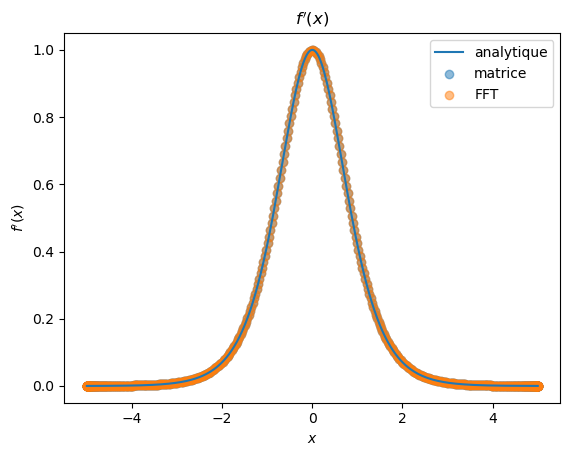

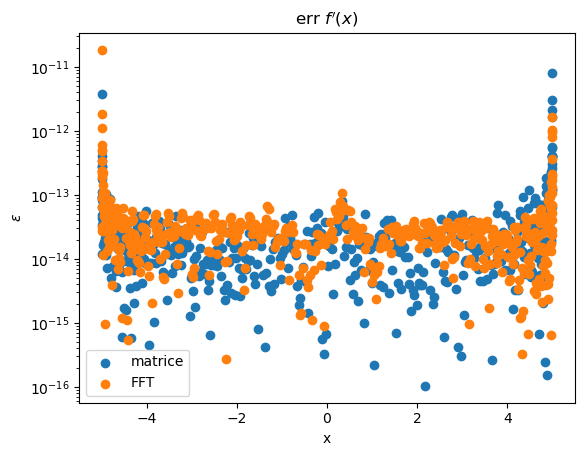

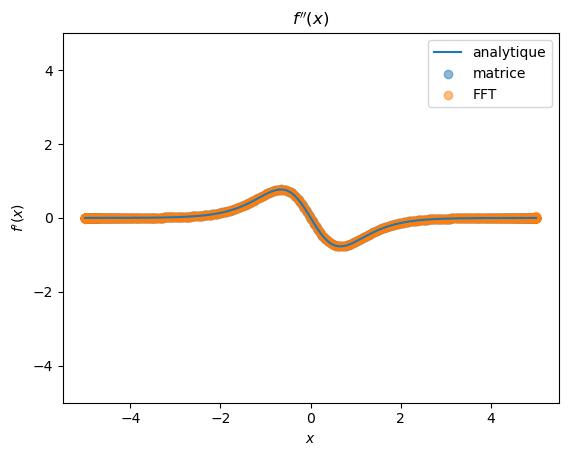

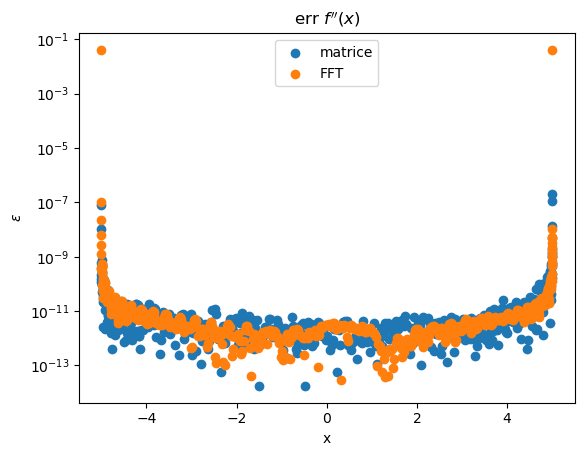

In [7]:
#Petit test sur la fonction tanh

f = lambda X : np.tanh(X)
#f = lambda X : np.exp(X)
f_prime = lambda X : 1./np.cosh(X)**2
f_pprime = lambda X : -2.*np.tanh(X)/(np.cosh(X)**2)

N=512

A =-5.0
B = 5.0

D= Cheb_diff(N, a= A, b= B)
x = collocation_points(N, a= A, b= B)

D2 = D@D

f_p_mat = D@f(x)
f_pp_mat =  D2@f(x)

f_p_FFT = Cheb_FFT(f(x), a= A, b=B)

f_pp_FFT = Cheb_second_FFT(f(x), a= A, b=B)
#f_pp_FFT = Cheb_FFT(Cheb_FFT(f(x), a= A, b =B), a=A, b=B)
fig = plt.figure()
plt.title(r"$f'(x)$")
plt.plot(x, f_prime(x), label = "analytique")
plt.scatter(x, f_p_mat, label = 'matrice', alpha = 0.5)
plt.scatter(x, f_p_FFT, label = 'FFT', alpha = 0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$f'(x)$")
plt.legend()

err_mat = np.abs(f_prime(x) - f_p_mat)
err_FFT = np.abs(f_prime(x) - f_p_FFT)

fig = plt.figure()
plt.title(r"err $f'(x)$")
plt.scatter(x, err_mat, label='matrice')
plt.scatter(x, err_FFT, label = 'FFT')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")
plt.yscale("log")
plt.legend()


fig = plt.figure()
plt.title(r"$f''(x)$")
plt.plot(x, f_pprime(x), label = "analytique")
plt.scatter(x, f_pp_mat, label = 'matrice', alpha = 0.5)
plt.scatter(x, f_pp_FFT, label = 'FFT', alpha = 0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$f'(x)$")
plt.legend()
plt.ylim(-5., 5.)

err_mat2 = np.abs(f_pprime(x) - f_pp_mat)
err_FFT2 = np.abs(f_pprime(x) - f_pp_FFT)

fig = plt.figure()
plt.title(r"err $f''(x)$")
plt.scatter(x, err_mat2, label='matrice')
plt.scatter(x, err_FFT2, label = 'FFT')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")
plt.yscale("log")
plt.legend()

# Test de la différenciation 2D (Chebyshev)

Pour des raisons de performance et de simplicité, j'utilise l'implémentation basée sur la FFT. 

**Attention à bien construire une grille irrégulière (points de Gauss-Lobatto). Déclarer ```x = np.linspace(-1., 1., N)```, c'est NON  (sinon malédiction sur vous pour les 30 générations à venir) !**

[[105.25278091 105.21929046 105.11881478 ... 105.11881478 105.21929046
  105.25278091]
 [105.2428755  105.20938821 105.10892199 ... 105.10892199 105.20938821
  105.2428755 ]
 [105.21316526 105.17968742 105.07924956 ... 105.07924956 105.17968742
  105.21316526]
 ...
 [105.21316526 105.17968742 105.07924956 ... 105.07924956 105.17968742
  105.21316526]
 [105.2428755  105.20938821 105.10892199 ... 105.10892199 105.20938821
  105.2428755 ]
 [105.25278091 105.21929046 105.11881478 ... 105.11881478 105.21929046
  105.25278091]]
x=0.49822766697278187
171
513
(513,)
y=6.123233995736766e-17
246


(-75.0, 75.0)

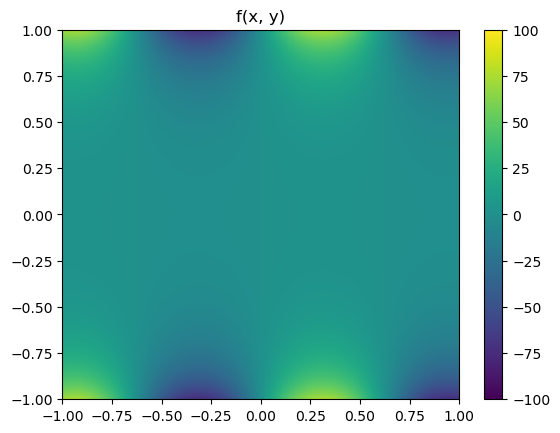

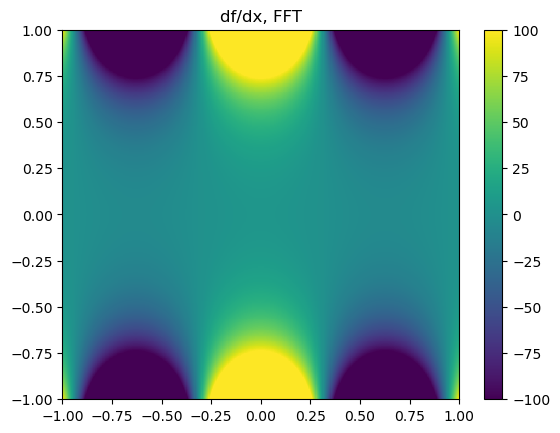

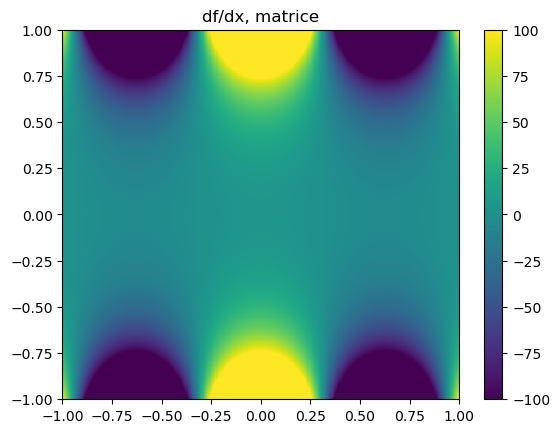

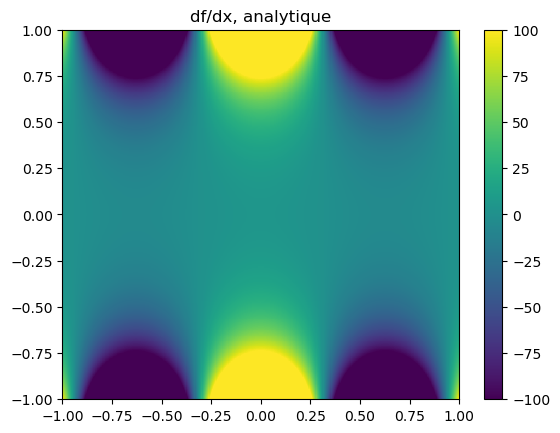

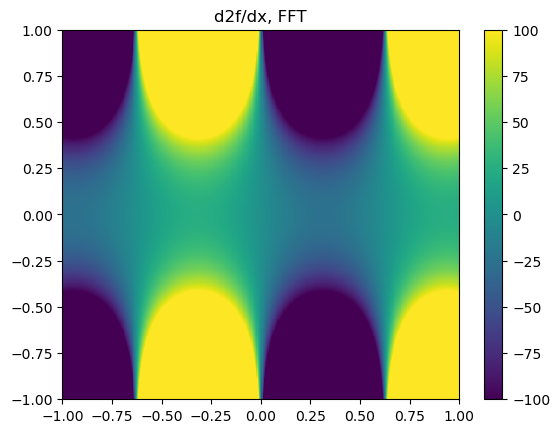

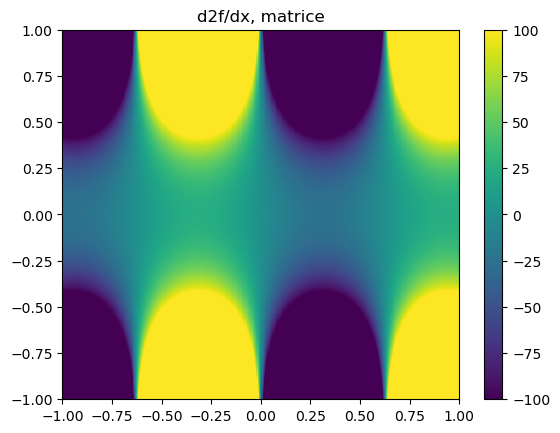

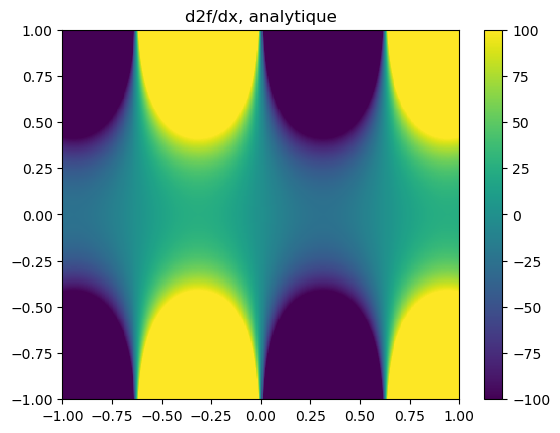

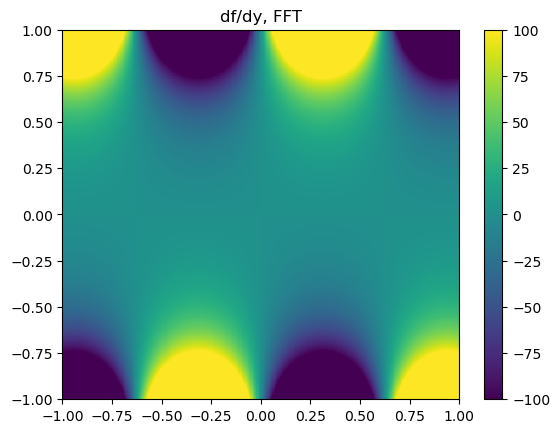

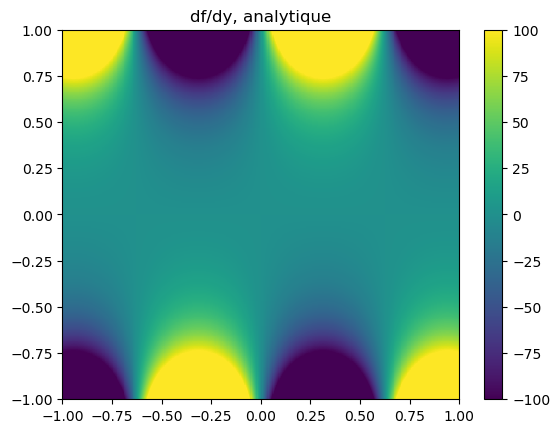

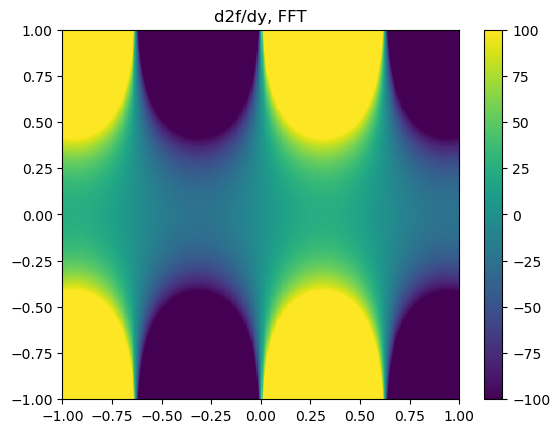

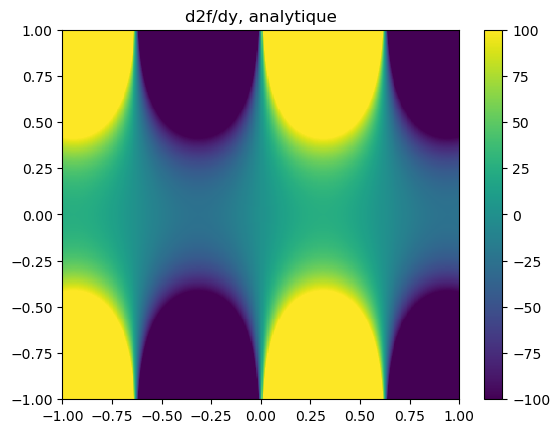

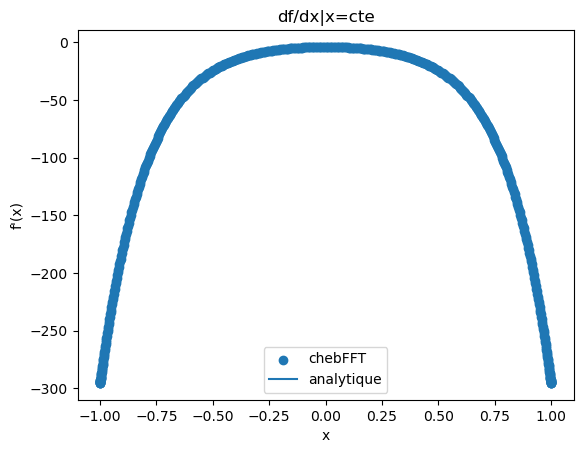

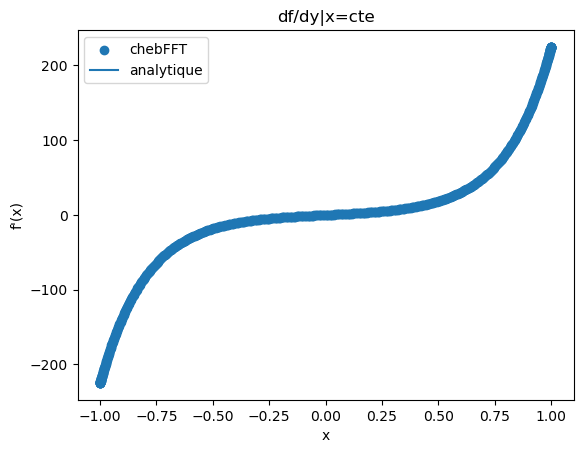

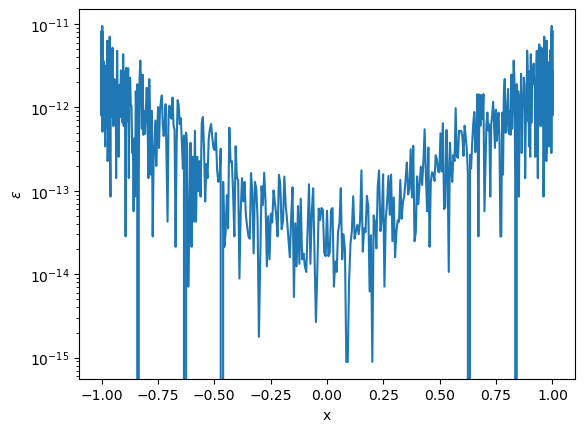

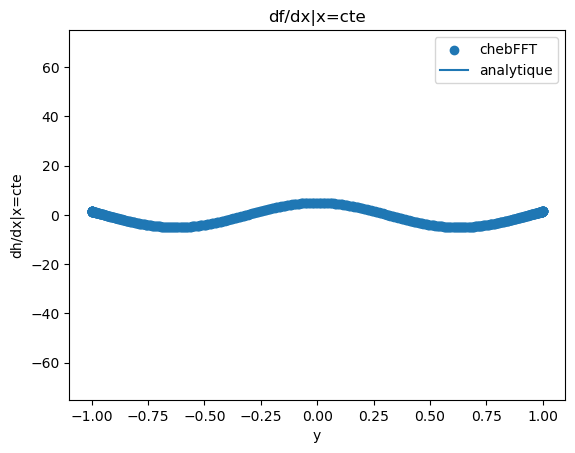

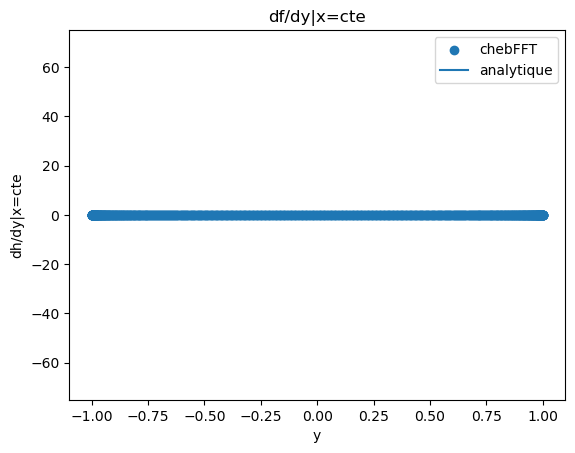

In [8]:
f = lambda x, y : np.sin(5.0*x)*np.cosh(5.0*y)

f_prime_x = lambda x, y : 5.0*np.cos(5.0*x)*np.cosh(5.0*y)
f_sec_x = lambda x, y : -25.0*f(x, y)

f_prime_y = lambda x, y : 5.0*np.sin(5.0*x)*np.sinh(5.0*y)
f_sec_y = lambda x, y : 25.0*f(x, y)

N=512
j = np.arange(N+1)
x = np.cos(np.pi * j / N)

X, Y = np.meshgrid(x, x)

f_x = f(X, Y)


def Cheb_FFT_2D(V, order = 1, axis ='x', a=-1., b= 1.):
    if order ==1 : 
        func_deriv = lambda xx : Cheb_FFT(xx, a=a, b=b)
    elif order == 2 : 
        #func_deriv = lambda xx : Cheb_second_FFT(xx, a=a, b=a)
        func_deriv = lambda xx : Cheb_FFT(Cheb_FFT(xx, a=a, b=b), a=a, b=b)
    else :
        raise ValueError
    
    if axis == 'x' or axis == 0 : 
        dVdx = np.zeros_like(V)
        for i in range(0, V.shape[0]):
            dVdx[i, :] = func_deriv(V[i, :])
        return dVdx
    elif axis == 'y' or axis == 1:
        dVdy = np.zeros_like(V)
        for i in range(0, V.shape[1]):
            dVdy[:, i] = func_deriv(V[:,i])
        return dVdy
    else:
        raise ValueError

df_dx = Cheb_FFT_2D(f_x, axis = 'x')
v_depart = np.cos(np.pi*np.arange(0, N+1)/N)
#print(v_depart)
print(df_dx)
#df_dx = Cheb_second_FFT(v_depart)
#print(df_dx)
d2f_dx = Cheb_FFT_2D(f_x, order =2, axis = 'x')


def Cheb_derivative_2D(V, order = 1, axis ='x', a = -1., b=1.):
    
    if axis == 'x' or axis == 0 : 
        dVdx = np.zeros_like(V)
        Nx = dVdx.shape[0]
        D = Cheb_diff(Nx, a=a, b=b)
        #D = D[1:-1, 1:-1]
        if order == 2 : 
            D = D@D
        for i in range(0, V.shape[1]):
            dVdx[i, :] = D@V[i, :]
        return dVdx
    elif axis == 'y' or axis == 1:
        dVdy = np.zeros_like(V)
        for i in range(0, V.shape[0]):
            dVdy[i, :] = func_deriv(V[i, :])
        return dVdy
    else:
        raise ValueError
df_dx_mat = Cheb_derivative_2D(f_x, axis = 'x')
d2f_dx_mat = Cheb_derivative_2D(f_x, order =2, axis = 'x')

f_prime_x_ana = f_prime_x(X, Y)
f_pprime_x_ana = f_sec_x(X, Y)


fig = plt.figure()
ax=plt.axes()
ax.set_title("f(x, y)")
cf = ax.pcolormesh(X, Y, f(X, Y), vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)


fig = plt.figure()
ax=plt.axes()
ax.set_title("df/dx, FFT")
cf = ax.pcolormesh(X, Y, df_dx, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dx, matrice")
cf = ax.pcolormesh(X, Y, df_dx_mat, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)

fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dx, analytique")
cf = ax.pcolormesh(X, Y, f_prime_x_ana, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dx, FFT")
cf = ax.pcolormesh(X, Y, d2f_dx, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dx, matrice")
cf = ax.pcolormesh(X, Y, d2f_dx_mat, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("d2f/dx, analytique")
cf = ax.pcolormesh(X, Y, f_pprime_x_ana, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)




df_dy = Cheb_FFT_2D(f_x, axis = 'y')
d2f_dy = Cheb_FFT_2D(f_x, order =2, axis = 'y')

fig = plt.figure()
ax=plt.axes()
ax.set_title("df/dy, FFT")
cf = ax.pcolormesh(X, Y, df_dy, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)




fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dy, analytique")
cf = ax.pcolormesh(X, Y, f_prime_y(X,Y), vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dy, FFT")
cf = ax.pcolormesh(X, Y, d2f_dy, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

#fig = plt.figure()
#ax=plt.axes()
#ax.set_title("d2f/dy, matrice")
#cf = ax.pcolormesh(X, Y, d2f_dx_mat, vmin =-5., vmax=5.)
#fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("d2f/dy, analytique")
cf = ax.pcolormesh(X, Y, f_sec_y(X,Y), vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

y_sel = 0.5

index_y = np.abs(x -y_sel).argmin()

index = N//2-10

print(f"x={x[index_y]}")
print(index_y)

print(x.size)
print(df_dx[:,index_y].shape)
fig = plt.figure()
plt.title("df/dx|x=cte")
plt.scatter(x, df_dx[:,index_y], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_x(X,Y)[:,index_y], label = 'analytique')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()



fig = plt.figure()
plt.title("df/dy|x=cte")
plt.scatter(x, df_dy[:,index_y], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_y(X,Y)[:,index_y], label = 'analytique')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()


err_y = np.abs(df_dx[:,index_y]-f_prime_x(X,Y)[:,index_y])

fig = plt.figure()
plt.plot(x, err_y)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

x_sel = 0.0

index_x = np.abs(x -x_sel).argmin()

index = N//2-10

print(f"y={x[index_x]}")
print(index)

fig = plt.figure()
plt.title("df/dx|x=cte")
plt.scatter(x, df_dx[index_x, :], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_x(X,Y)[index_x, :], label = 'analytique')
plt.xlabel('y')
plt.ylabel("dh/dx|x=cte")
plt.legend()
plt.ylim(-75., 75.)

fig = plt.figure()
plt.title("df/dy|x=cte")
plt.scatter(x, df_dy[index_x, :], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_y(X,Y)[index_x, :], label = 'analytique')
plt.xlabel('y')
plt.ylabel("dh/dy|x=cte")
plt.legend()
plt.ylim(-75., 75.)

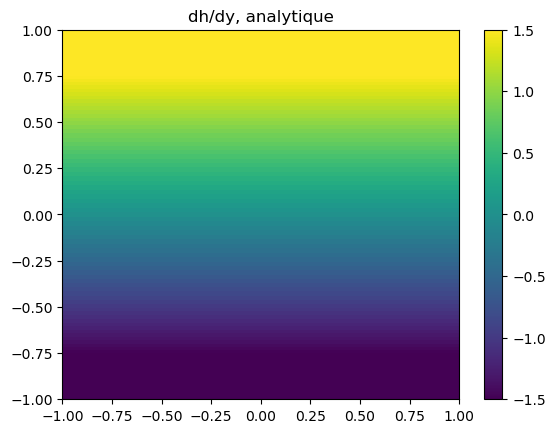

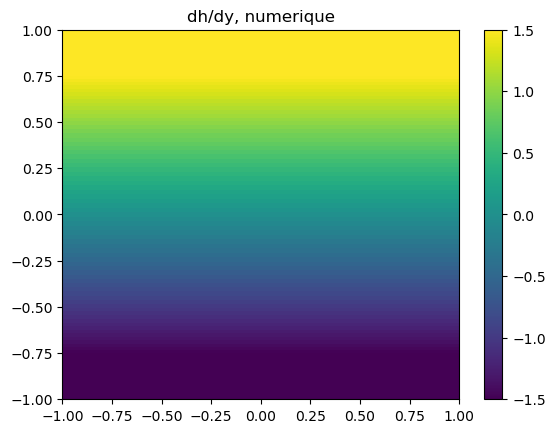

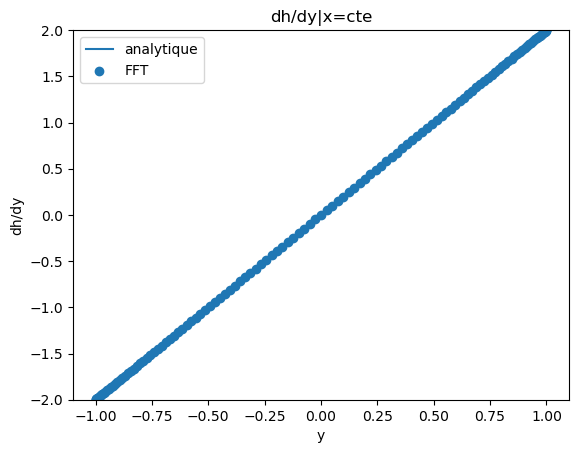

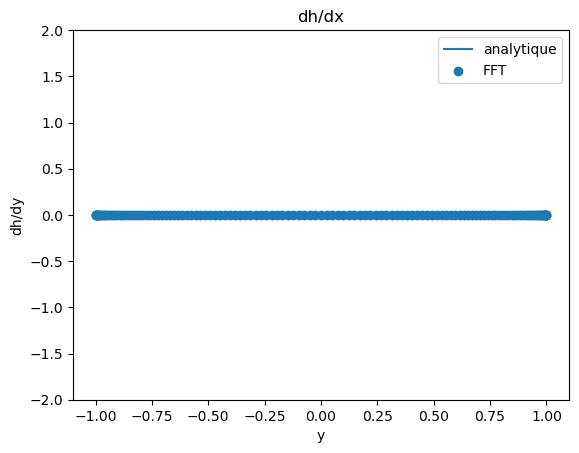

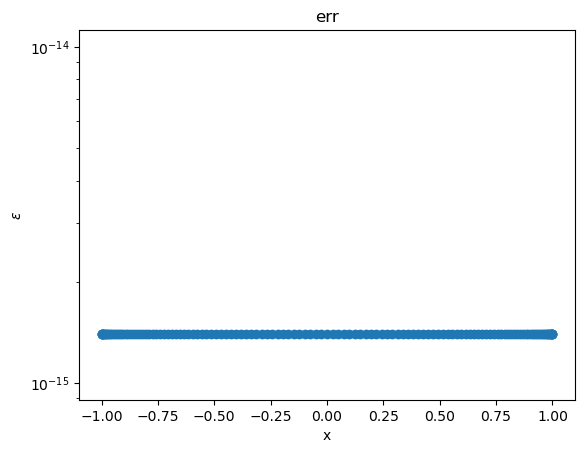

In [9]:
#h = lambda x, y : np.cosh(y)
#h_py = lambda x, y : np.sinh(y)

h = lambda x, y : y**2
h_py = lambda x, y: 2.*y
h_ppy = lambda x, y : 2.*np.ones_like(y)
#h = lambda x, y : y
#h_py = lambda x, y : 1.*np.ones(y.shape)

N=128
j = np.arange(N+1)
x = np.cos(np.pi * j / N)

Y, X = np.meshgrid(x, x, indexing = 'ij')


dh_dy = Cheb_FFT_2D(h(X, Y), axis = 'y')
dh_dx = Cheb_FFT_2D(h(X, Y), axis = 'x')


fig = plt.figure()

ax=plt.axes()
ax.set_title("dh/dy, analytique")
cf = ax.pcolormesh(X, Y, h_py(X,Y), vmin = -1.5, vmax =1.5)
fig.colorbar(cf, ax=ax)


fig = plt.figure()
ax=plt.axes()
ax.set_title("dh/dy, numerique")
cf = ax.pcolormesh(X, Y, dh_dy, vmin = -1.5, vmax =1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
plt.title("dh/dy|x=cte")
plt.plot(x, h_py(X, Y)[:, N//2], label = 'analytique')
plt.scatter(x, dh_dy[:, N//2], label = 'FFT')
plt.legend()
plt.xlabel('y')
plt.ylabel("dh/dy")
plt.ylim(-2., 2.)

fig  = plt.figure()
plt.title("dh/dx")
plt.plot(x, np.zeros_like(dh_dx[:, N//2]), label = 'analytique')
plt.scatter(x, dh_dx[:, N//2], label = 'FFT')
plt.legend()
plt.xlabel('y')
plt.ylabel("dh/dy")
plt.ylim(-2., 2.)


fig = plt.figure()
plt.title('err')
err = np.abs(h_py(X, Y)[N//2, :]-dh_dy[N//2, :])
plt.scatter(x, err)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

In [10]:
h(X, Y)

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.99939773, 0.99939773, 0.99939773, ..., 0.99939773, 0.99939773,
        0.99939773],
       [0.99759236, 0.99759236, 0.99759236, ..., 0.99759236, 0.99759236,
        0.99759236],
       ...,
       [0.99759236, 0.99759236, 0.99759236, ..., 0.99759236, 0.99759236,
        0.99759236],
       [0.99939773, 0.99939773, 0.99939773, ..., 0.99939773, 0.99939773,
        0.99939773],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]])

# Advection 1D périodique

 k = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31. -32. -31. -30. -29. -28. -27. -26. -25. -24. -23.
 -22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.
  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.]
y_hat = [-9.59685761e-15-0.00000000e+00j -6.96110302e-15-2.27174787e-15j
 -1.43444819e-14-1.15000935e-14j  3.20000000e+01-3.66212780e-14j
  4.37775359e-15+1.60294471e-14j  5.20641271e-15+1.06173340e-14j
  8.52549424e-15+1.05741841e-15j  2.46959768e-15+1.46579699e-14j
 -2.89006920e-15+2.17711090e-14j -1.53319347e-14-1.46635649e-15j
 -1.69171138e-15-1.86638343e-14j -1.62175535e-15-6.43020925e-15j
  2.84282506e-15+4.77815172e-15j  8.88178420e-16+2.05962794e-16j
  9.17814082e-15+1.05447170e-16j -2.50512402e-14-1.67100858e-15j
  5.33564207e-15-9.43689571e-15j -1.74925971e-15-8.23141180e-15j
 -1.41090685e-14-2.00565815e-15j -8.88178420e-16-1.08641038e-14j
 -7.3574473

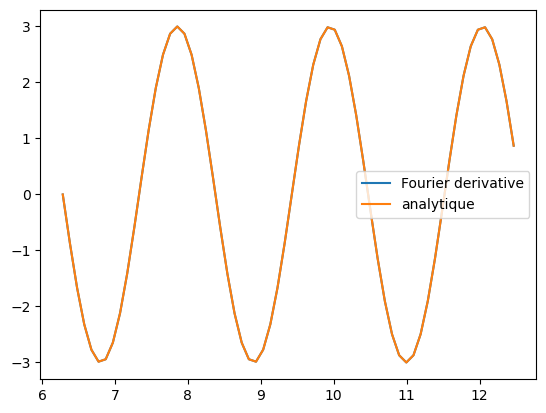

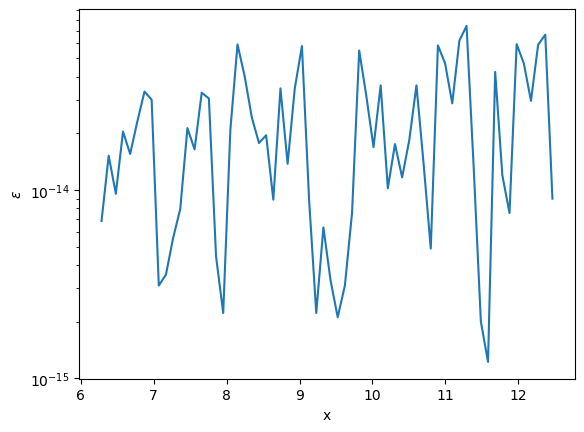

In [11]:
#Derivée Fourier 1D

def dx_Fourier_1D(y, a = 0., b = 2.0*np.pi, real = True, print_k =False):
    k = 2*np.pi * scipy.fft.fftfreq(y.size, d=((b-a)/y.size))
    y_hat = scipy.fft.fft(y)
    y_p = (scipy.fft.ifft(1.j*k*y_hat))
    if print_k:
        print(f" k = {k}")
        print(f"y_hat = {y_hat}")
        print(f"y_p = {y_p}")
    res = y_p
    if real : 
        res = y_p.real
    return 2.0*np.pi/(b-a)*res

#test


fig = plt.figure()
X = np.linspace(2.0*np.pi, 4.0*np.pi,64, endpoint= False)

f_x= np.cos(3.*X)
fp_x = -3.*np.sin(3.*X)

Df_dx = dx_Fourier_1D(f_x,a=2.*np.pi, b=4.*np.pi, print_k =True)
#print(Df_dx)
plt.plot(X, Df_dx, label='Fourier derivative')
plt.plot(X, fp_x, label= 'analytique')
plt.legend()

err_Fourier = np.abs(Df_dx -fp_x)

fig = plt.figure()
plt.plot(X, err_Fourier)
plt.xlabel('x')
plt.ylabel(r'$\epsilon$')
plt.yscale('log')


Nx = 128
dx = 0.0078125
c=100.0
dt = 7.8125e-07
u_sum(0) = 31.834164319855336


C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(31.0, 33.0)

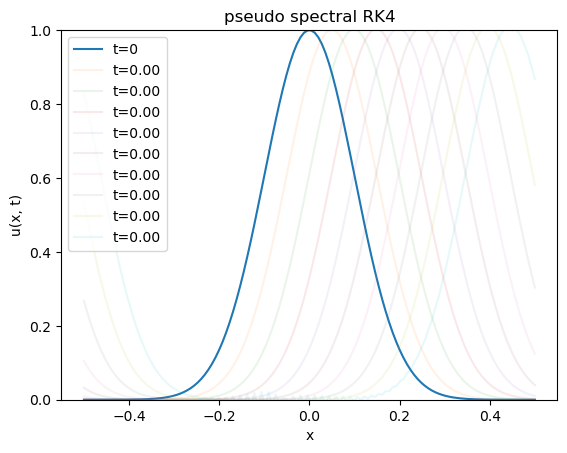

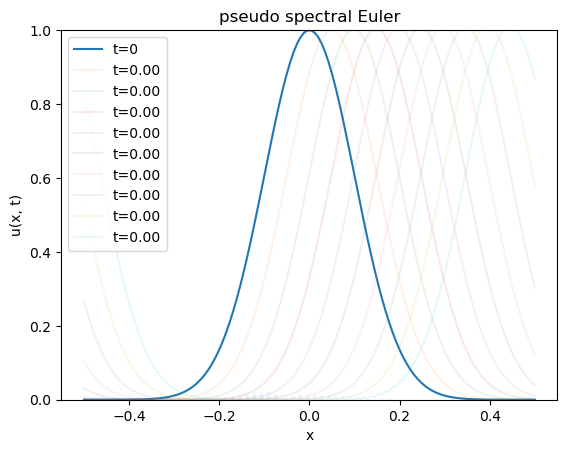

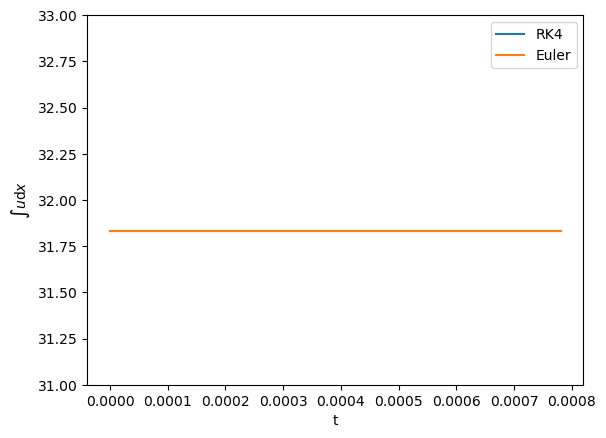

In [12]:
L = 1.0

Nx = 128

print(f"Nx = {Nx}")

x = np.linspace(-L/2., L/2., Nx)

sigma = 0.1
u0 = np.exp( -x**2/(2.*sigma**2) )
u = u0.copy()

dx = L/Nx

CFL = 0.01

print(f"dx = {dx}")

c=100.0
print(f"c={c}")


dt = CFL*dx/c
#dt =1.0e-6


print(f"dt = {dt}")

Nt = 1000

u_res = [u]

t=0.0
t_tot = [t]

time_scheme ='Euler'

u_int = u

def RK4(x, rhs, delta_t, *args, **kwargs):
    k1 = rhs(x, *args, **kwargs)
    k2 = rhs(x+0.5*delta_t*k1, *args, **kwargs)
    k3 = rhs(x+0.5*delta_t*k2, *args, **kwargs)
    k4 = rhs(x+delta_t*k3, *args, **kwargs)

    return x+delta_t*(k1+2.0*k2+2.0*k3+k4)/6.0

def u_tot(U):
    return np.sum(U)
def rhs_adv(x):
    return -c*dx_Fourier_1D(u, a=-L/2., b=L/2., real =False)

u_int =[u_tot(u)]
print(f"u_sum(0) = {u_tot(u0)}")

u_euler = u0.copy()
u_euler_t = [u_euler]
u_int_euler = [u_tot(u)]

for i in range(0, Nt):
    u_euler = u_euler - c*dt*dx_Fourier_1D(u_euler, a=-L/2., b=L/2.)#intégration par méthode d'Euler
    u = RK4(u, rhs_adv, dt)
    u_res.append(u)
    u_int.append(u_tot(u))
    u_int_euler.append(u_tot(u_euler))
    u_euler_t.append(u_euler)
    t+=dt
    t_tot.append(t)


Da_1D = xr.DataArray(np.array(u_res).real, dims=['t', 'x'], coords = {'x' : x, 't':t_tot})

step_plot =100

fig = plt.figure()
plt.title("pseudo spectral RK4")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_res[i], label=f't={i*dt:.2f}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_euler_t[i], label=f't={i*dt:.2f}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()
plt.plot(t_tot, u_int, label = 'RK4')
plt.plot(t_tot, u_int, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()
plt.ylim(31., 33.)

## Résolution de l'équation de Helmholtz en configuration "canal périodique" avec CLs de Dirichlet en $y=\pm 1$

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \pm \sinh(l)\sin(kx)$, $RHS(x, y)=0$. La solution est $\psi(x, y) = \sin(kx)\sinh(ly)$ pour $\alpha = k^2-l^2$


Au début, on prends $\psi(x, y) = \sinh(y)$, $\psi(x, \pm 1) = \pm \sinh(1)$, $\alpha = 2$, $RHS(x, y) = -\sinh(y)$ (lignes commentées)

In [13]:
#dérivée de cosh

N = 512
D, xx = Cheb_diff(N-1)

D2 = D@D

f_x =np.cosh(xx)

f_pp_x = D2@f_x
err_f = np.abs(f_pp_x - np.cosh(xx))

print(f"cond(D2) {np.linalg.cond(D2):.3e}")
print(f"cond(D2[1:-1, 1:-1]) {np.linalg.cond(D2[1:-1, 1:-1]):.3e}")

fig = plt.figure()
plt.title(r"$f(x) = \cosh(x)$, calcul de $f''(x)$ avec matrice")
plt.plot(xx, err_f)
plt.yscale('log')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")

ValueError: too many values to unpack (expected 2)

X.shape (512, 512)
Y.shape (512, 512)
alpha^2 2.0
psi_num.shape (512, 512)
kx = [   0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.
   12.   13.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.
   24.   25.   26.   27.   28.   29.   30.   31.   32.   33.   34.   35.
   36.   37.   38.   39.   40.   41.   42.   43.   44.   45.   46.   47.
   48.   49.   50.   51.   52.   53.   54.   55.   56.   57.   58.   59.
   60.   61.   62.   63.   64.   65.   66.   67.   68.   69.   70.   71.
   72.   73.   74.   75.   76.   77.   78.   79.   80.   81.   82.   83.
   84.   85.   86.   87.   88.   89.   90.   91.   92.   93.   94.   95.
   96.   97.   98.   99.  100.  101.  102.  103.  104.  105.  106.  107.
  108.  109.  110.  111.  112.  113.  114.  115.  116.  117.  118.  119.
  120.  121.  122.  123.  124.  125.  126.  127.  128.  129.  130.  131.
  132.  133.  134.  135.  136.  137.  138.  139.  140.  141.  142.  143.
  144.  145.  146.  147.  148.  149.  150.  

C:\Users\evanl\AppData\Local\Temp\ipykernel_17104\2008442624.py:191: RuntimeWarning: invalid value encountered in divide
  ratio = psi_num_hat[kx==k, :]/psi_ana_hat[kx==k, :]
C:\Users\evanl\AppData\Local\Temp\ipykernel_17104\2008442624.py:192: RuntimeWarning: invalid value encountered in divide
  ratio_n = psi_num_hat[kx==-k, :]/psi_ana_hat[kx==-k, :]


ratio = [[nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj
  nan+nanj nan+nanj nan+nanj n

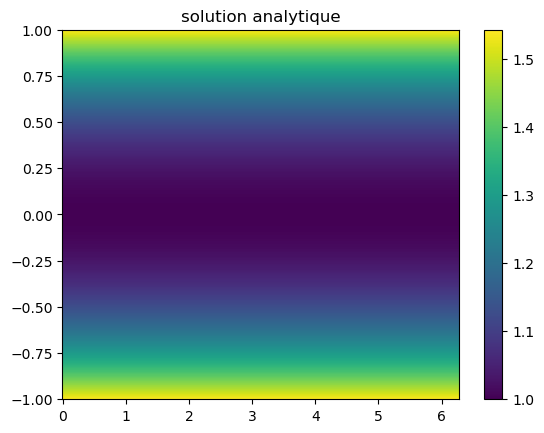

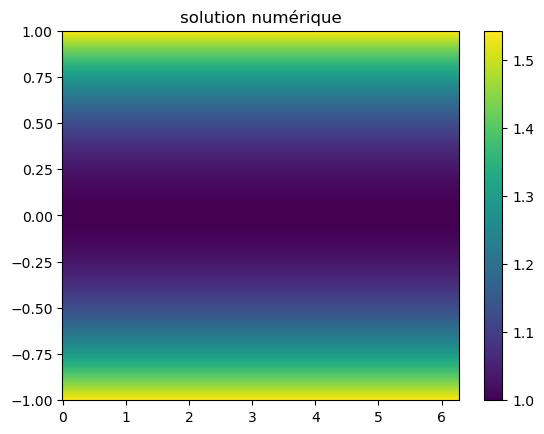

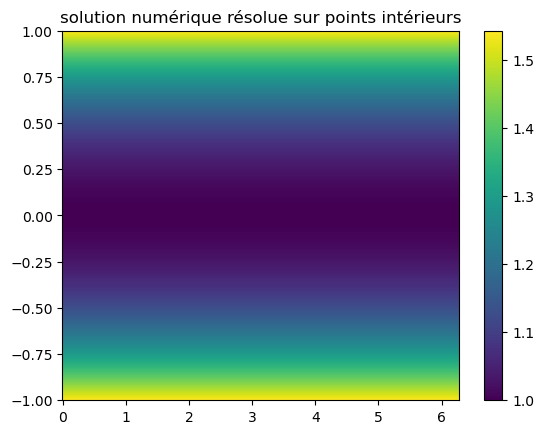

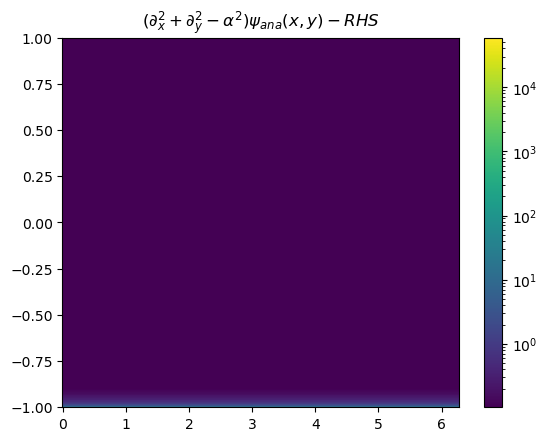

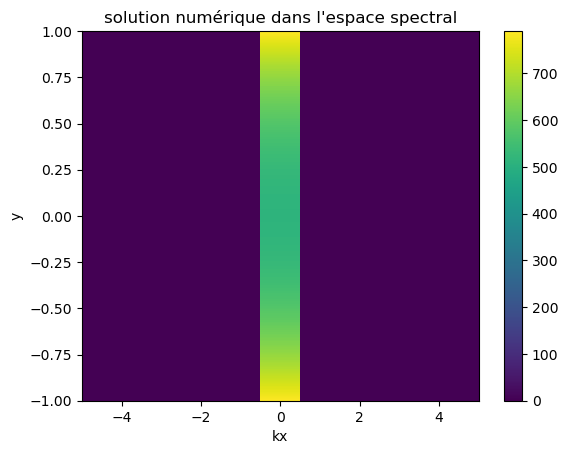

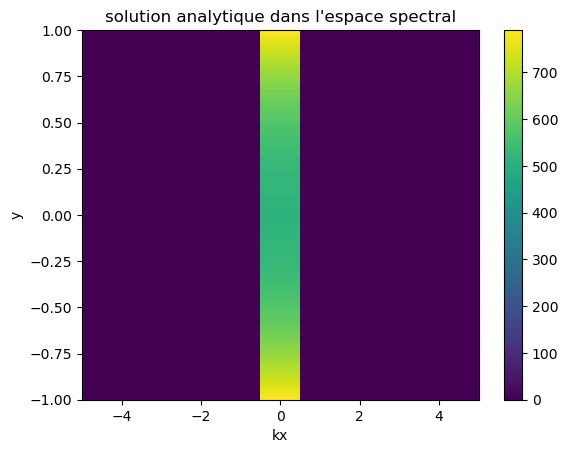

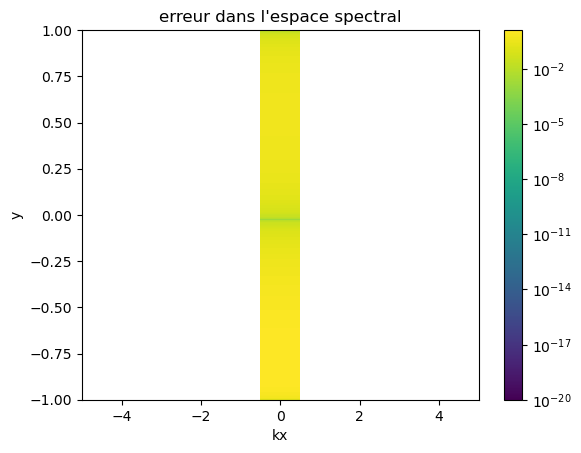

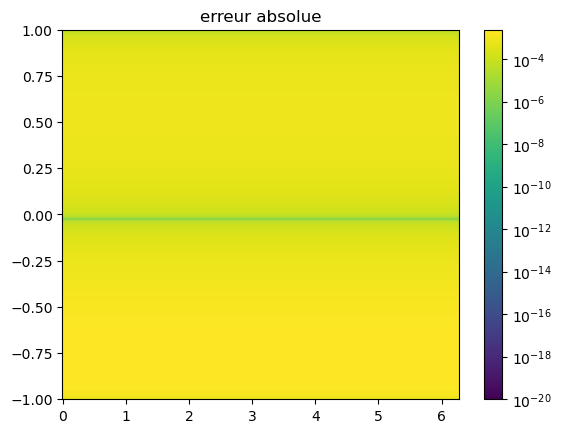

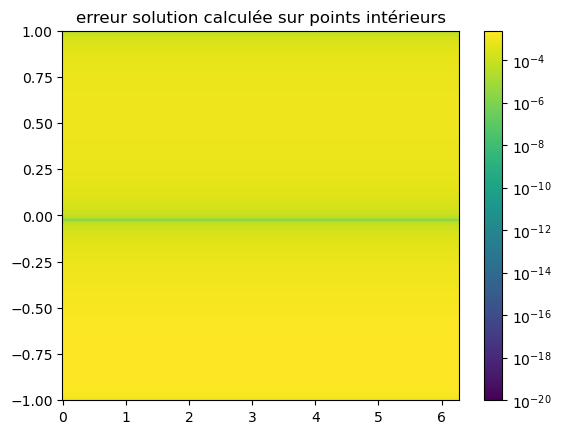

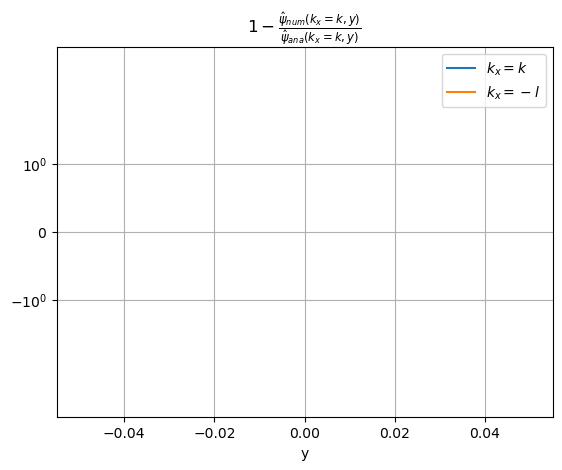

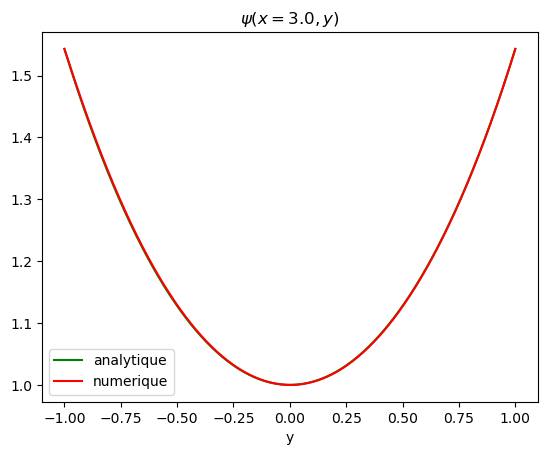

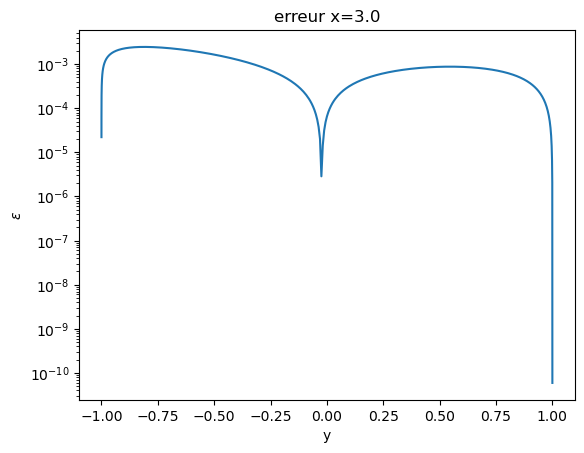

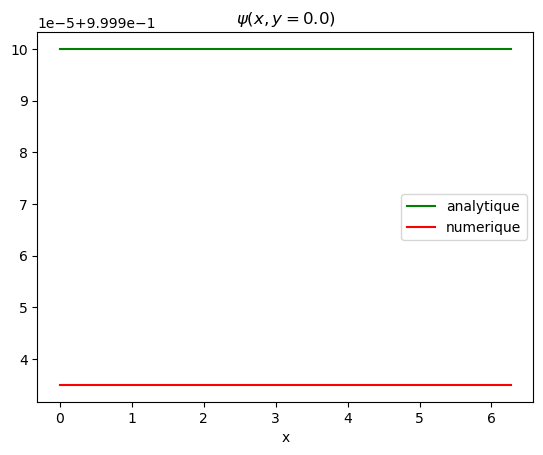

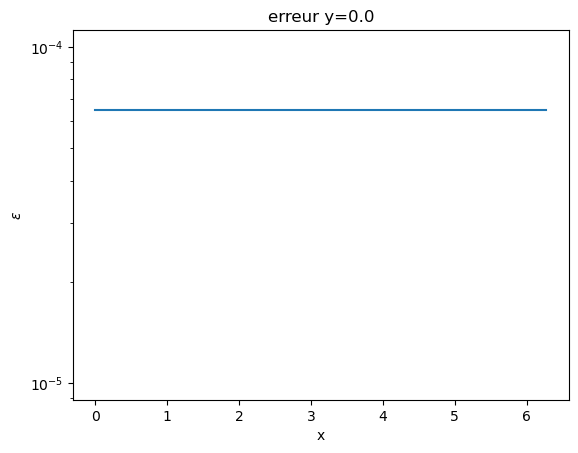

In [18]:
Nx= 512
Ny = 512
#Construction de la grille
j = np.arange(Ny)
y = np.cos(np.pi * j / Ny)

x_inf = 0.0
x_sup = 2.*np.pi

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2 = 2.*l**2
#alpha2 = -(k**2-l**2)

print(f'alpha^2 {alpha2}')

psi_num = np.zeros((Nx, Ny))
#rhs = np.zeros((Nx, Ny))
rhs = -np.cosh(l*Y)
helmh_ana = np.zeros((Nx, Ny), dtype = 'complex')

residus = np.zeros_like(psi_num, dtype = 'complex')

rhs_hat = scipy.fft.fft(rhs, axis = 0)
psi_num_hat = np.zeros((Nx, Ny), dtype = 'complex')
psi_num_hat_2=np.zeros((Nx, Ny), dtype = 'complex')
#print(rhs_hat)

print(f"psi_num.shape {psi_num.shape}")

#CLs de Dirichlet: 
bc_y1 = np.cosh(l) * np.ones(Nx)
bc_ym1 = bc_y1.copy()

#bc_y1 = np.cosh(l)*np.sin(k*x)
#bc_ym1 = bc_y1.copy()

bc_y1_hat = scipy.fft.fft(bc_y1)
bc_ym1_hat = scipy.fft.fft(bc_ym1)

psi_analytique = np.cosh(l*Y)
#psi_analytique = np.cosh(l*Y)*np.sin(k*X)
psi_ana_hat = scipy.fft.fft(psi_analytique, axis= 0)


kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/x.size)#A re-vérifier
print(f"kx = {kx}")


D = Cheb_diff(Ny)
D2 = D@D
#D2 = D2[1:-1, 1:-1]

print(f"D2.shape {D2.shape}")
print(f"D2 = {D2}")

for i in range(0, Nx) : 
    rhs_hat_i = rhs_hat[i, :].copy()
    rhs_hat_i[0] = bc_y1_hat[i]
    rhs_hat_i[-1] = bc_ym1_hat[i]
    kx_i = kx[i]
    F = -(kx_i**2 +alpha2)*np.eye(Ny)
    F[0, 0] = 1.
    F[-1, -1] = 1.
    F[1:-1, :] += D2[1:-1, :]
    inv_F = np.linalg.inv(F)
    psi_hat_i = inv_F @ rhs_hat_i
    psi_num_hat[i, :] = psi_hat_i
    #####Autre formulation#####################"#
    G = F[1:-1, 1:-1]#on prends les bords intérieurs
    rhs_hat_i_2 = rhs_hat[i, 1:-1]- F[1:-1, 0]*bc_y1_hat[i] - F[1:-1, -1]*bc_ym1_hat[i]
    print((rhs_hat[i, 1:-1]- F[1:-1, 0]*bc_y1_hat[i] - F[1:-1, -1]*bc_ym1_hat[i]) == (rhs_hat[i, 1:-1]- D2[1:-1, 0]*bc_y1_hat[i] - D2[1:-1, -1]*bc_ym1_hat[i]))
    inv_G = np.linalg.inv(G)
    psi_hat_i_2 = inv_G @ rhs_hat_i_2
    psi_num_hat_2[i, 1:-1] = psi_hat_i_2
    psi_num_hat_2[i, 0] = bc_y1_hat[i]
    psi_num_hat_2[i, -1] = bc_ym1_hat[i]
    
    #residus[i, :] = ( D2- ( kx_i**2 + alpha2 )*np.eye(Ny) ) @ psi_hat_i
    helmh_ana[i, :] = F@psi_ana_hat[i, :]
    if kx_i == k or kx_i ==-k :
        print(f"kx = {k}")
        print(f"F = {F}")
        print(f"G ={G}")
        #print(f"residus : (D2-(kx^2+alpha^2)*I)@psi_hat : {residus[i, :]}")
        #print(f"Helmholtzien(sol) = {helmh_ana[i, :]}")
        #print(f"RHS : {rhs_hat[i, :]}")
        res = F @ psi_hat_i - rhs_hat_i
        print(np.max(np.abs(res[1:-1])))
        print(f"cond(F) {np.linalg.cond(F):.2f}")
        print(f"cond(G) {np.linalg.cond(G):.2f}")
#calcul de la FFT inverse
psi_num_cpx = scipy.fft.ifft(psi_num_hat, axis = 0)
psi_num = psi_num_cpx.real
psi_num2 = scipy.fft.ifft(psi_num_hat_2, axis = 0).real

print(f"max(Im(psi_num_hat) ) = {np.max(np.abs(psi_num_hat.imag))}")
print(f"max(Im(psi_num_cpx) ) = {np.max(np.abs(psi_num_cpx.imag))}")

helmh_ana = scipy.fft.ifft(helmh_ana, axis =0).real

print(psi_num)
    
#err_op = np.abs(helmh_ana -rhs_hat).real

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique résolue sur points intérieurs")
cf = ax.pcolormesh(X, Y, psi_num2)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title(r"$(\partial_x^2+\partial_y^2 -\alpha^2)\psi_{ana}(x,y) -RHS$")
#cf = ax.pcolormesh(X, Y, helmh_ana - rhs, norm=colors.SymLogNorm(0.1, vmin=helmh_ana.min(), vmax=helmh_ana.max()))
cf = ax.pcolormesh(X, Y, np.abs(helmh_ana - rhs), norm=colors.LogNorm( vmin=np.abs(helmh_ana).min(), vmax=np.abs(helmh_ana).max()))
fig.colorbar(cf, ax=ax)


psi_hat_norm = np.abs(psi_num_hat)

KX, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')


def sort_k(z_hat,K):
    new_z_hat = z_hat.copy()

    K_argsort = np.argsort(K)
    for i in range(0, z_hat.shape[0]):
        new_z_hat[i, :] = z_hat[K_argsort[i], :]
    return new_z_hat
fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique dans l'espace spectral")
cf = ax.pcolormesh(KX, Y, sort_k(psi_hat_norm, kx))
fig.colorbar(cf, ax=ax)
plt.xlabel('kx')
plt.ylabel('y')
plt.xlim(-5., 5.)



fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique dans l'espace spectral")
cf = ax.pcolormesh(KX, Y, sort_k(np.abs(psi_ana_hat), kx))
fig.colorbar(cf, ax=ax)
plt.xlabel('kx')
plt.ylabel('y')
plt.xlim(-5., 5.)


fig  = plt.figure()
err_spec = np.abs(psi_ana_hat-psi_num_hat)
ax=plt.axes()
ax.set_title("erreur dans l'espace spectral")
cf = ax.pcolormesh(KX, Y, sort_k(err_spec, kx), norm=colors.LogNorm(vmin=1.0e-20, vmax=err_spec.max()))
fig.colorbar(cf, ax=ax)
plt.xlabel('kx')
plt.ylabel('y')
plt.xlim(-5., 5.)

##Tracé de l'erreur

err = np.abs(psi_analytique - psi_num)
err_2 = np.abs(psi_analytique - psi_num2)

err_L2 = np.linalg.norm(err)
err_rel_L2 = err_L2/np.linalg.norm(psi_analytique)

ratio = psi_num_hat[kx==k, :]/psi_ana_hat[kx==k, :] 
ratio_n = psi_num_hat[kx==-k, :]/psi_ana_hat[kx==-k, :] 
print(f"ratio = {ratio}")

print(f"err {err_L2}")
print(f"err_L2_rel {err_rel_L2}")


print(f"err_rel max {err_rel_L2.max():f} (Ny = {Ny}, Nx = {Nx})")
print(f"err_rel min {err_rel_L2.min():f}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, np.abs(err), norm=colors.LogNorm(vmin=1.0e-20, vmax=err.max()))
fig.colorbar(cf, ax=ax)


fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur solution calculée sur points intérieurs")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-20, vmax=err.max()))
fig.colorbar(cf, ax=ax)

fig = plt.figure()
plt.title(r"$1-\frac{\hat{\psi}_{num}(k_x = k, y)}{\hat{\psi}_{ana}(k_x = k, y)}$")
plt.plot(y, 1.-ratio[0].real, label = r"$k_x = k$")
plt.plot(y, 1. - ratio_n[0].real, label = r"$k_x = -l$")
plt.xlabel("y")
plt.ylim(-5., 5.)
plt.grid(True)
plt.yscale('symlog')
plt.legend()
#Transects
x_sel = 3.0
x_index = np.abs(x-x_sel).argmin()
psi_ana_sel_y = psi_analytique[x_index, :]
psi_num_sel_y = psi_num[x_index, :]

fig = plt.figure()
plt.title(rf"$\psi(x= {x_sel}, y)$")
plt.plot(y, psi_ana_sel_y, label='analytique', color = 'g')
plt.plot(y, psi_num_sel_y, label = 'numerique', color = 'r')
plt.xlabel('y')
plt.legend()

err_sel_y = err[x_index, :]
fig = plt.figure()
plt.title(f"erreur x={x_sel}")
plt.plot(y, err_sel_y)
plt.xlabel('y')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')


y_sel = 0.0
y_index = np.abs(y-y_sel).argmin()
psi_ana_sel_x = psi_analytique[:, y_index]
psi_num_sel_x = psi_num[:, y_index]

print(f"psi_ana_sel_x {psi_ana_sel_x}")
print(f"psi_num_sel_x {psi_num_sel_x}")

fig = plt.figure()
plt.title(rf"$\psi(x,y= {y_sel})$")
plt.plot(x, psi_ana_sel_x, label='analytique', color = 'g')
plt.plot(x, psi_num_sel_x, label = 'numerique', color = 'r')
plt.xlabel('x')
plt.legend()

err_sel_x = err[:, y_index]
fig = plt.figure()
plt.title(f"erreur y={y_sel}")
plt.plot(x, err_sel_x)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

In [ ]:
#Cas à 1 mode

#(d2/dy^2 - 2)psi = RHS
#psi=cosh(y), RHS = -cosh(y)

N=512
D,yy = Cheb_diff(N-1)
D2 = D@D
print(f"N = {N}")
Psi = np.cosh(yy)
F = -2.*np.eye(N)
F[0, 0] = 1.
F[-1, -1] = 1.
F[1:-1, :] += D2[1:-1, :]

RHS = F@Psi

Psi_num = np.linalg.solve(F, RHS)

fig = plt.figure()
plt.plot(yy, Psi, label = 'analytique')
plt.plot(yy, Psi_num, label = 'numerique')
plt.plot(yy, RHS, label = 'RHS')
plt.xlabel('y')
plt.legend()

Err = np.abs(Psi_num - Psi)/Psi
fig = plt.figure()
plt.title('erreur')
plt.plot(yy, Err)
plt.xlabel('y')
plt.yscale('log')

In [ ]:
psi_num_hat.imag

In [ ]:
helmh_ana
 

In [ ]:
fig = plt.figure()
plt.hist(np.abs(np.ravel(helmh_ana)), bins =1000)
plt.xscale('log')
plt.xlim(1.0e-13, 1.0e3)

In [ ]:
print(err.min())
print(err.max())

In [ ]:
np.sort(kx)

## Divers

In [ ]:
np.__version__

In [ ]:
scipy.__version__

In [ ]:
x = np.arange(0, 25).reshape((5, 5))
print(x)
print(x[0,:])
print(x[:, 0])
print(x.shape)
print("########################################")
for i in range(0, x.shape[0]):
    print(x[i, :])

print("########################################")
for i in range(0, x.shape[1]):
    print(x[:, i])
print("########################################")
new_x = x[1:-1, 1:-1]
print(new_x)
print(new_x.shape)

In [ ]:
np.flip([1, 2, 3])

In [ ]:
x = np.linspace(0., 2.*np.pi, 32)
g = np.exp(np.sin(x))
g_hat = scipy.fft.fft(g)
g_hat_inv = scipy.fft.ifft(g_hat)
print(f"g = {g}")
print(f"ifft(fft(g)) = {g_hat_inv.real}")
residual = np.abs(g_hat_inv - g)
print(f"residu : {residual}")

In [ ]:
x = np.linspace(0., 2.*np.pi, 32)
x_false = np.linspace(0., 2.*np.pi, 32, endpoint = False)
print(f"endpoint = True {x}, size = {x.size}")
print(f"endpoint = False {x_false}, size = {x_false.size}")